# Notebook 2 — Monant · Baseline Classifier (full_data)
## Pipeline TF-IDF -> Classifieurs ML · Baseline 4 classes

**Projet :** A Multi-Source Benchmark for CVD Health Misinformation Detection  
**Dataset :** full_data (claims.csv)  
**Objectif :** reproduce the same baseline: `false`, `almost false` (mean mostly fale), `almost true` (mean mostl true), `true`
---
### What does this notebook do?
1. Load `full_data/claims.csv`
2. Build a 4-class label from claim ratings
3. Prepare TF-IDF
4. Train baseline classifiers:
   - Logistic Regression
   - Naive Bayes
   - LinearSVC
5. Evaluate with 5-fold cross-validation
6. Evaluate on held-out test set (80/20)
7. Analyze errors and discriminant features
8. Produce table

---
## Section 1 — Installation & imports

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, cross_validate
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(' Imports OK')

 Imports OK


---
## Section 2 — Data Loading (filtered thematic dataset)
Le notebook utilise le CSV filtré cardio + diabète généré depuis NB1 (`full_data/claims_cardio_diabete_filtered.csv`).

In [2]:
from pathlib import Path

CSV_PATH = Path('full_data/claims_cardio_diabete_filtered.csv')
if not CSV_PATH.exists():
    raise FileNotFoundError(
        'Filtered dataset not found: full_data/claims_cardio_diabete_filtered.csv\n'
        'Run NB1 first to generate it.'
    )

raw_df = pd.read_csv(CSV_PATH, encoding='utf-8', low_memory=False)
print(f'All data loaded: {len(raw_df)} thematic claims')
print(f'CSV used: {CSV_PATH}')

All data loaded: 1278 thematic claims
CSV used: full_data/claims_cardio_diabete_filtered.csv


In [3]:
print('── Missing values (raw claims) ──')
print(raw_df.isnull().sum().to_string())
print()

# Mapping 4 classes des ratings
# accepte aussi les variantes 'mostly-*' et 'almost *'
rating_aliases = {
    'false': 'false',
    'mostly-false': 'almost false',
    'almost false': 'almost false',
    'mostly true': 'almost true',
    'mostly-true': 'almost true',
    'almost true': 'almost true',
    'true': 'true',
}

class_order = ['false', 'almost false', 'almost true', 'true']

df = raw_df.copy()
df['rating_norm'] = (
    df['rating']
    .astype(str)
    .str.strip()
    .str.lower()
)

df['label_name'] = df['rating_norm'].map(rating_aliases)
df = df[df['label_name'].isin(class_order)].copy()

# id numérique (utile pour exports/compatibilité)
label_to_id = {c: i for i, c in enumerate(class_order)}
df['label'] = df['label_name'].map(label_to_id).astype(int)

# Colonne texte: combine name + statement + description
text_parts = []
for col in ['name', 'statement', 'description']:
    if col in df.columns:
        text_parts.append(df[col].fillna('').astype(str))

if not text_parts:
    raise ValueError('Aucune colonne texte exploitable parmi name/statement/description.')

df['text'] = text_parts[0]
for part in text_parts[1:]:
    df['text'] = df['text'] + ' ' + part

df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()
df = df[df['text'].astype(bool)].copy()

# On conserve le rating brut pour l'analyse d'erreurs
if 'rating' in df.columns:
    df['rating_raw'] = df['rating']

print('── Dataset 4 classes construit depuis claims.csv ──')
print(f'Claims conservés : {len(df)}')
print('Répartition des classes:')
print(df['label_name'].value_counts().reindex(class_order, fill_value=0).to_string())
print('')
print('Répartition rating_norm (brut):')
print(df['rating_norm'].value_counts().to_string())

X = df['text'].values
y = df['label_name'].values

── Missing values (raw claims) ──
id                0
name           1271
statement         0
description      81
category          0
rating          260
queries        1271
created_at        0
updated_at        0

── Dataset 4 classes construit depuis claims.csv ──
Claims conservés : 732
Répartition des classes:
label_name
false           504
almost false     60
almost true      31
true            137

Répartition rating_norm (brut):
rating_norm
false           504
true            137
mostly-false     60
mostly-true      31


---
## Section 3 —  Train / Test
Use stratified split 80/20

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

train_counts = pd.Series(y_train).value_counts().reindex(class_order, fill_value=0)
test_counts = pd.Series(y_test).value_counts().reindex(class_order, fill_value=0)

print('── Split Train / Test ──')
print(f'  Train : {len(X_train)} claims')
print(train_counts.to_string())
print(f'  Test  : {len(X_test)} claims')
print(test_counts.to_string())

── Split Train / Test ──
  Train : 585 claims
false           403
almost false     48
almost true      25
true            109
  Test  : 147 claims
false           101
almost false     12
almost true       6
true             28


---
## Section 4 — Construction of pipelines

### Paramètres TF-IDF 
| Paramètre | Valeur | Justification |
|---|---|---|
| `ngram_range` | (1, 2) | Capture les expressions bi-mot ('heart disease', 'clinical trial') |
| `max_features` | 10 000 | Limite le bruit tout en couvrant le vocabulaire médical |
| `sublinear_tf` | True | Compresse les fréquences élevées (log(1+tf)) — standard NLP |
| `stop_words` | english | Retire les mots vides non informatifs |
| `min_df` | 2 | Ignore les termes n'apparaissant qu'une seule fois |
| `max_df` | 0.95 | Ignore les termes présents dans >95% des docs |


In [5]:
# Vectorizer common to both models
TFIDF_PARAMS = dict(
    ngram_range  = (1, 2),
    max_features = 10_000,
    sublinear_tf = True,
    stop_words   = 'english',
    min_df       = 2,
    max_df       = 0.95
)

# ── Pipeline 1 :  Logistic Regression 
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',  LogisticRegression(
        C           = 1.0,       # regularization L2 standard
        max_iter    = 1000,
        random_state= RANDOM_STATE,
        class_weight= 'balanced' 
    ))
])

# ── Pipeline 2 : Naive Bayes Multinomial 
pipe_nb = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',  MultinomialNB(alpha=0.5))  # α=0.5 : lissage de Lidstone
])

# ── Pipeline 3 : LinearSVC
pipe_svm = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',  LinearSVC(
        C           = 1.0,
        max_iter    = 2000,
        random_state= RANDOM_STATE,
        class_weight= 'balanced'
    ))
])

models = {
    'Logistic Regression': pipe_lr,
    'Naive Bayes':         pipe_nb,
    'LinearSVC':           pipe_svm,
}


for name, pipe in models.items():
    print(f'   • {name}')

   • Logistic Regression
   • Naive Bayes
   • LinearSVC


---
## Section 5 — crossed validation


In [16]:
from sklearn.model_selection import cross_validate
import joblib

# n_splits dynamics to handle rare classes in filtered dataset

min_class_count = pd.Series(y).value_counts().min()
n_splits = max(2, min(5, int(min_class_count)))
SKF = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

print(f'Using StratifiedKFold with n_splits={n_splits} (min class count={min_class_count})')
cv_results = {}
for name, pipe in models.items():
    cv = cross_validate(
        pipe, X, y,
        cv      = SKF,
        scoring = {
            'accuracy'        : 'accuracy',
            'f1_macro'        : 'f1_macro',
            'precision_macro' : 'precision_macro',
            'recall_macro'    : 'recall_macro',
        },
        return_train_score = False,
        n_jobs = -1
    )
    cv_results[name] = cv
    joblib.dump(cv_results, "cv_results_normal.joblib")
    
    print(f'── {name} ──')
    print(f'  Accuracy  : {cv["test_accuracy"].mean():.4f} ± {cv["test_accuracy"].std():.4f}')
    print(f'  F1 macro  : {cv["test_f1_macro"].mean():.4f} ± {cv["test_f1_macro"].std():.4f}')
    print(f'  Precision : {cv["test_precision_macro"].mean():.4f} ± {cv["test_precision_macro"].std():.4f}')
    print(f'  Recall    : {cv["test_recall_macro"].mean():.4f} ± {cv["test_recall_macro"].std():.4f}')
    print()

Using StratifiedKFold with n_splits=5 (min class count=31)
── Logistic Regression ──
  Accuracy  : 0.6967 ± 0.0320
  F1 macro  : 0.4045 ± 0.0328
  Precision : 0.4193 ± 0.0431
  Recall    : 0.4048 ± 0.0327

── Naive Bayes ──
  Accuracy  : 0.6885 ± 0.0045
  F1 macro  : 0.2039 ± 0.0008
  Precision : 0.1721 ± 0.0011
  Recall    : 0.2500 ± 0.0000

── LinearSVC ──
  Accuracy  : 0.7103 ± 0.0265
  F1 macro  : 0.3094 ± 0.0536
  Precision : 0.4285 ± 0.1479
  Recall    : 0.3130 ± 0.0391



---
## Section 6 — Entraînement final et évaluation sur le test set
On entraîne sur le train set complet et on évalue sur le test set réservé.

In [7]:
test_results = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    report_dict = classification_report(
        y_test, y_pred,
        labels=class_order,
        target_names=class_order,
        output_dict=True,
        zero_division=0
    )

    per_class_f1 = {
        c: float(report_dict.get(c, {}).get('f1-score', 0.0))
        for c in class_order
    }

    test_results[name] = {
        'y_pred'         : y_pred,
        'accuracy'       : accuracy_score(y_test, y_pred),
        'prec_macro'     : precision_score(y_test, y_pred, average='macro', zero_division=0),
        'rec_macro'      : recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_macro'       : f1_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_weighted'    : f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'per_class_f1'   : per_class_f1,
    }

    print(f'── {name} — Test Set ──')
    print(classification_report(
        y_test, y_pred,
        labels=class_order,
        target_names=class_order,
        zero_division=0
    ))

── Logistic Regression — Test Set ──
              precision    recall  f1-score   support

       false       0.77      0.82      0.79       101
almost false       0.18      0.17      0.17        12
 almost true       0.00      0.00      0.00         6
        true       0.46      0.46      0.46        28

    accuracy                           0.67       147
   macro avg       0.35      0.36      0.36       147
weighted avg       0.63      0.67      0.65       147

── Naive Bayes — Test Set ──
              precision    recall  f1-score   support

       false       0.69      1.00      0.81       101
almost false       0.00      0.00      0.00        12
 almost true       0.00      0.00      0.00         6
        true       0.00      0.00      0.00        28

    accuracy                           0.69       147
   macro avg       0.17      0.25      0.20       147
weighted avg       0.47      0.69      0.56       147

── LinearSVC — Test Set ──
              precision    recall  f1

---
## Section 7 — confused matrix

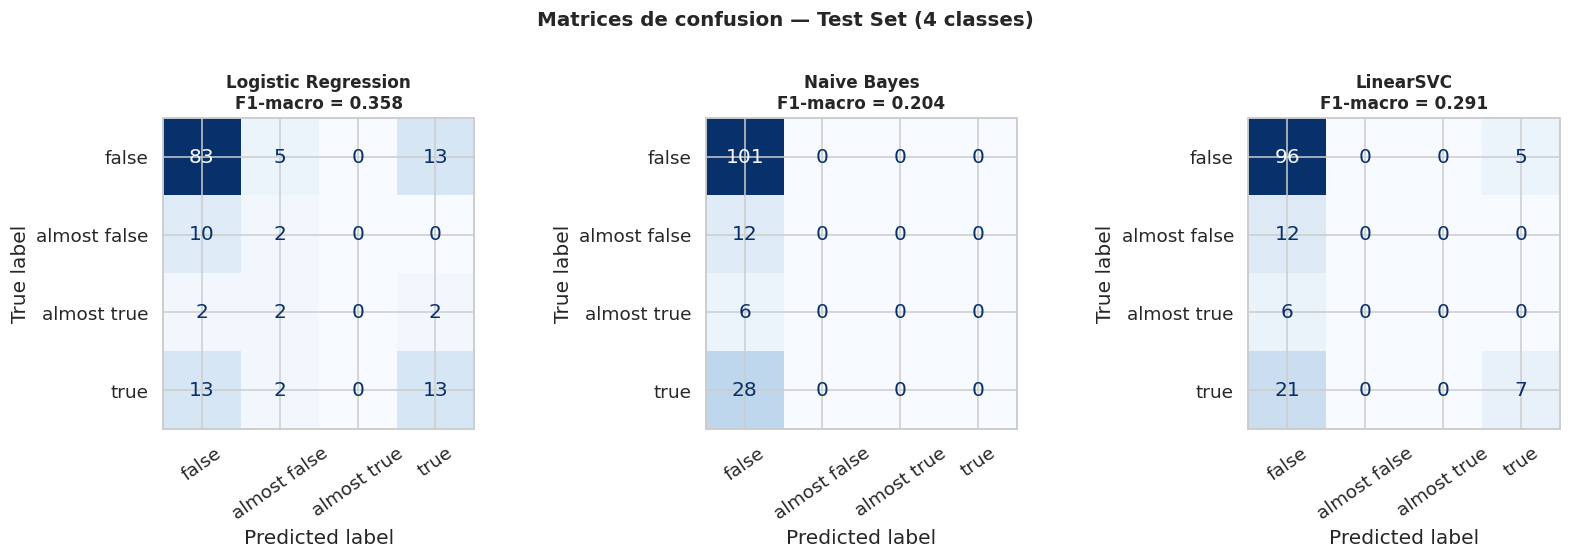

In [15]:
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.8))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'], labels=class_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=35)
    ax.set_title(f'{name}\nF1-macro = {res["f1_macro"]:.3f}', fontsize=11, fontweight='bold')

plt.suptitle('Matrices de confusion — Test Set (4 classes)', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()

plt.show()


---
## Section 8 — Features most discriminants
Pour la Régression Logistique,  coefficients indicates wchich word move on Fake ou Real.

In [9]:
import re

# Extraction des features importantes (Logistic Regression multiclasse)
lr_pipe = models['Logistic Regression']
vectorizer = lr_pipe.named_steps['tfidf']
classifier = lr_pipe.named_steps['clf']

feature_names = vectorizer.get_feature_names_out()
classes = list(classifier.classes_)

# Analyse ciblée sur les termes médicaux hérités de NB1
cardiovascular_diseases = [
    'cardiovascular disease', 'heart disease', 'coronary artery disease',
    'ischemic heart disease', 'myocardial infarction', 'heart attack',
    'stroke', 'ischemic stroke', 'hypertension', 'high blood pressure',
    'heart failure', 'arrhythmia'
]

cardiovascular_symptoms = [
    'chest pain', 'angina', 'shortness of breath', 'dyspnea', 'palpitations',
    'fatigue', 'dizziness', 'syncope', 'edema'
]

cardiovascular_risk_factors = [
    'smoking', 'tobacco use', 'obesity', 'bmi', 'high cholesterol', 'ldl', 'hdl',
    'diabetes', 'sedentary lifestyle', 'family history', 'age'
]

cardiovascular_treatments = [
    'statins', 'beta-blockers', 'antihypertensive drugs', 'aspirin therapy',
    'angioplasty', 'stent', 'bypass surgery'
]

cardiovascular_tests = [
    'ecg', 'electrocardiogram', 'blood pressure', 'cholesterol levels',
    'troponin', 'echocardiogram'
]

diabetes_types = [
    'type 1 diabetes', 'type 2 diabetes', 'gestational diabetes', 'prediabetes'
]

diabetes_symptoms = [
    'frequent urination', 'polyuria', 'excessive thirst', 'polydipsia',
    'fatigue', 'weight loss', 'blurred vision', 'slow wound healing'
]

diabetes_treatments = [
    'insulin', 'metformin', 'glucose-lowering drugs', 'glp-1 agonists',
    'lifestyle intervention', 'diet control'
]

diabetes_biomarkers = [
    'blood glucose', 'fasting glucose', 'hba1c', 'insulin level', 'glucose tolerance test'
]

diabetes_complications = [
    'neuropathy', 'nephropathy', 'retinopathy', 'cardiovascular disease', 'diabetic foot ulcer'
]

medical_general_terms = [
    'risk factor', 'prevalence', 'incidence', 'mortality', 'clinical trial',
    'diagnosis', 'treatment outcome', 'patient', 'hospital', 'clinical study',
    'randomized controlled trial', 'medical record', 'electronic health records',
    'clinical notes', 'medical report'
]

term_groups = {
    'cardiovascular_diseases': cardiovascular_diseases,
    'cardiovascular_symptoms': cardiovascular_symptoms,
    'cardiovascular_risk_factors': cardiovascular_risk_factors,
    'cardiovascular_treatments': cardiovascular_treatments,
    'cardiovascular_tests': cardiovascular_tests,
    'diabetes_types': diabetes_types,
    'diabetes_symptoms': diabetes_symptoms,
    'diabetes_treatments': diabetes_treatments,
    'diabetes_biomarkers': diabetes_biomarkers,
    'diabetes_complications': diabetes_complications,
    'medical_general_terms': medical_general_terms,
}

def _normalize_term(term):
    return re.sub(r'\s+', ' ', str(term).strip().lower())

def _extract_matching_ngrams(term):
    t = _normalize_term(term)
    tokens = re.findall(r'[a-z0-9]+', t)
    if not tokens:
        return []
    if len(tokens) <= 2:
        return [' '.join(tokens)]
    cands = [' '.join(tokens[i:i+2]) for i in range(len(tokens) - 1)]
    cands.extend(tokens)
    seen = set()
    out = []
    for c in cands:
        if c not in seen:
            out.append(c)
            seen.add(c)
    return out

rows = []
for group_name, terms in term_groups.items():
    for term in terms:
        candidates = _extract_matching_ngrams(term)
        matched = [c for c in candidates if c in feature_names]

        if not matched:
            rows.append({
                'group': group_name,
                'term': term,
                'matched_features': '',
                'n_matched_features': 0,
                'best_class': 'not_found',
                'best_coef': np.nan,
            })
            continue

        idx = [np.where(feature_names == m)[0][0] for m in matched]
        mean_by_class = classifier.coef_[:, idx].mean(axis=1)
        best_i = int(np.argmax(mean_by_class))

        rows.append({
            'group': group_name,
            'term': term,
            'matched_features': ', '.join(matched),
            'n_matched_features': len(matched),
            'best_class': classes[best_i],
            'best_coef': float(mean_by_class[best_i]),
        })

target_df = pd.DataFrame(rows)
target_found = target_df[target_df['n_matched_features'] > 0].copy()

print('Target terms matched in TF-IDF vocabulary:')
print(f'  Found: {len(target_found)} / {len(target_df)}')
if not target_found.empty:
    display(target_found.sort_values('best_coef', ascending=False).head(30))

Target terms matched in TF-IDF vocabulary:
  Found: 37 / 88


,group,term,matched_features,n_matched_features,best_class,best_coef
31,cardiovascular_risk_factors,age,age,1,true,0.838371
23,cardiovascular_risk_factors,obesity,obesity,1,true,0.808200
6,cardiovascular_diseases,stroke,stroke,1,true,0.594011
21,cardiovascular_risk_factors,smoking,smoking,1,almost true,0.527386
81,medical_general_terms,hospital,hospital,1,true,0.515477
67,diabetes_biomarkers,glucose tolerance test,"glucose, test",2,almost false,0.392041
17,cardiovascular_symptoms,fatigue,fatigue,1,true,0.353923
53,diabetes_symptoms,fatigue,fatigue,1,true,0.353923
80,medical_general_terms,patient,patient,1,true,0.278585
46,diabetes_types,type 2 diabetes,"type, diabetes",2,almost false,0.207054


---
## Section 9 — Analyse des erreurs
Quels articles sont mal classifiés ? Y a-t-il des patterns dans les erreurs ?

In [10]:
# Analyse d'erreurs (multiclasse) avec LR comme modèle principal
y_pred_lr = test_results['Logistic Regression']['y_pred']

all_indices = np.arange(len(df))
_, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df['label_name']
)

test_df = df.iloc[test_indices].copy().reset_index(drop=True)
test_df['y_true'] = np.asarray(y_test)
test_df['y_pred'] = np.asarray(y_pred_lr)
test_df['correct'] = (test_df['y_true'] == test_df['y_pred'])

errors = test_df[~test_df['correct']].copy()

print(f'Erreurs totales : {len(errors)} / {len(test_df)} ({100*len(errors)/len(test_df):.1f}%)')
print()

conf_pairs = (
    errors.groupby(['y_true', 'y_pred'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

print('Top confusions (true -> predicted):')
if conf_pairs.empty:
    print('  Aucune erreur.')
else:
    print(conf_pairs.head(10).to_string(index=False))

Erreurs totales : 49 / 147 (33.3%)

Top confusions (true -> predicted):
      y_true       y_pred  count
        true        false     13
       false         true     13
almost false        false     10
       false almost false      5
 almost true         true      2
 almost true        false      2
 almost true almost false      2
        true almost false      2


In [11]:
print('── Exemples d’erreurs par paire de confusion (LR) ──')

if errors.empty:
    print('Aucune erreur sur le test set.')
else:
    shown = 0
    for _, pair in conf_pairs.head(4).iterrows():
        true_c = pair['y_true']
        pred_c = pair['y_pred']
        subset = errors[(errors['y_true'] == true_c) & (errors['y_pred'] == pred_c)]
        if subset.empty:
            continue

        row = subset.iloc[0]
        txt = str(row.get('text', row.get('statement', 'N/A')))[:300]
        rating = row.get('rating_raw', row.get('rating_norm', 'N/A'))

        print(f'\nTrue={true_c} -> Pred={pred_c} | example rating={rating}')
        print(f'  {txt}...')
        shown += 1

    if shown == 0:
        print('Pas d’exemple disponible.')

── Exemples d’erreurs par paire de confusion (LR) ──

True=true -> Pred=false | example rating=true
  In November 2021, Austria's federal government announced it would impose mandatory nationwide COVID-19 vaccination from February 2022 onwards. Yes, Austria Announced Compulsory Nationwide COVID-19 Vaccination Amid a sharp rise in COVID-19 cases and considerable vaccine hesitancy, the federal governm...

True=false -> Pred=true | example rating=false
  Photograph shows a patient who received a severe penile burn from urinating on an electric fence. Does a Photograph Show a Penile Burn from an Electric Fence? Photograph purportedly shows a medical patient who received a severe penile burn from urinating on an electric fence. Although tales about me...

True=almost false -> Pred=false | example rating=mostly-false
  The CDC is setting up COVID-19 containment camps called "green zones. Is the CDC Setting Up ‘Green Zones’ or COVID-19 Containment Camps? A months-old document exploring one po

---
## Section 10 — Comparaison des modèles (visualisation)
Graphique comparatif des métriques pour les 3 modèles.

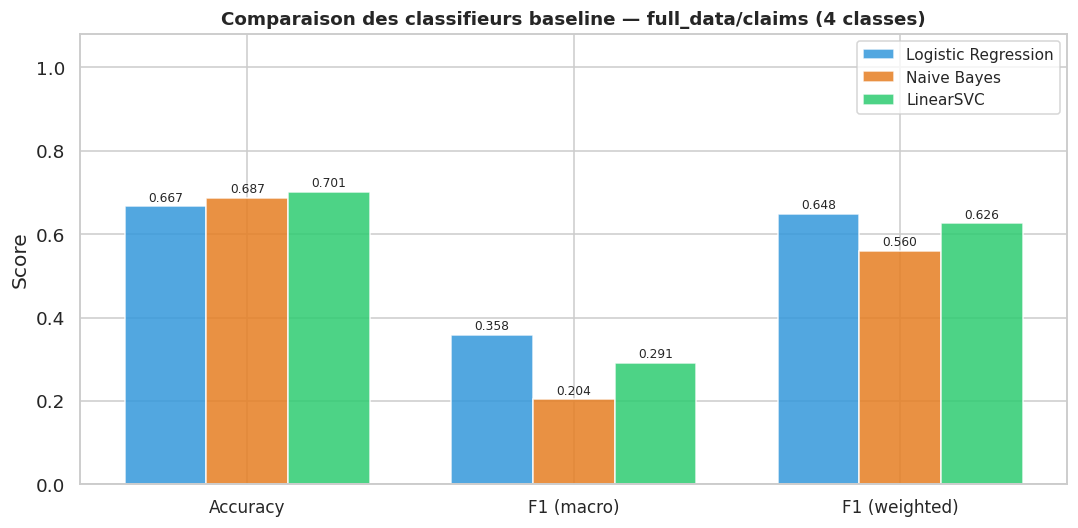

In [14]:
# Données de comparaison (multiclasse)
metrics = ['accuracy', 'f1_macro', 'f1_weighted']
metric_labels = ['Accuracy', 'F1 (macro)', 'F1 (weighted)']

x = np.arange(len(metrics))
width = 0.25
colors = ['#3498db', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(10, 5))

for i, (name, res) in enumerate(test_results.items()):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=name,
                  color=colors[i], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Comparaison des classifieurs baseline — full_data/claims (4 classes)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()

plt.show()



## Section 11 — TABLE 1 

In [13]:

print('TABLE 1 — Baseline Classifier Performance — cardio+diabete filtered claims (4 classes)')
print('Classes  : false | almost false | almost true | true')
print('Features : TF-IDF unigrammes + bigrammes (max 10 000 features)')
print('Split    : 80% train / 20% test (stratifié) | Validation : 5-fold CV')


header = f'{"Modèle":<24} {"Acc":>7} {"Prec":>7} {"Recall":>7} {"F1-mac":>7} {"F1-w":>7} {"CV F1±σ":>13}'
print(header)
print('-' * 92)

for name, res in test_results.items():
    cv = cv_results[name]
    cv_f1_mean = cv['test_f1_macro'].mean()
    cv_f1_std = cv['test_f1_macro'].std()
    row = (
        f'{name:<24} '
        f'{res["accuracy"]:>7.3f} '
        f'{res["prec_macro"]:>7.3f} '
        f'{res["rec_macro"]:>7.3f} '
        f'{res["f1_macro"]:>7.3f} '
        f'{res["f1_weighted"]:>7.3f} '
        f'{cv_f1_mean:>6.3f}±{cv_f1_std:.3f}'
    )
    print(row)

print('-' * 92)
print('\nF1 par classe (test set):')
for name, res in test_results.items():
    f1c = res['per_class_f1']
    print(
        f'  {name:<24} '
        f'false={f1c["false"]:.3f} | '
        f'almost false={f1c["almost false"]:.3f} | '
        f'almost true={f1c["almost true"]:.3f} | '
        f'true={f1c["true"]:.3f}'
    )



TABLE 1 — Baseline Classifier Performance — cardio+diabete filtered claims (4 classes)
Classes  : false | almost false | almost true | true
Features : TF-IDF unigrammes + bigrammes (max 10 000 features)
Split    : 80% train / 20% test (stratifié) | Validation : 5-fold CV
Modèle                       Acc    Prec  Recall  F1-mac    F1-w       CV F1±σ
--------------------------------------------------------------------------------------------
Logistic Regression        0.667   0.354   0.363   0.358   0.648  0.404±0.033
Naive Bayes                0.687   0.172   0.250   0.204   0.560  0.204±0.001
LinearSVC                  0.701   0.324   0.300   0.291   0.626  0.309±0.054
--------------------------------------------------------------------------------------------

F1 par classe (test set):
  Logistic Regression      false=0.794 | almost false=0.174 | almost true=0.000 | true=0.464
  Naive Bayes              false=0.815 | almost false=0.000 | almost true=0.000 | true=0.000
  LinearSVC     